In [1]:
# Cell 1 — Setup & Imports
import sys
import os
sys.path.append(os.path.abspath("../app/rag"))

from loader import load_documents
from chunker import chunk_documents

print(" Imports successful!")
print(f"Python version: {sys.version}")

 Imports successful!
Python version: 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]


In [2]:
# Cell 2 — Load Documents + Stats
docs_path = os.path.abspath("../data/sample_support_docs")
docs = load_documents(docs_path)

print(f"\n Total Documents: {len(docs)}")
print(f"\n{'='*40}")
for doc in docs:
    word_count = len(doc['content'].split())
    char_count = len(doc['content'])
    print(f"📄 {doc['filename']}")
    print(f"   Words: {word_count} | Chars: {char_count}")
    print(f"{'='*40}")

 Loaded: account_deletion_policy.txt
 Loaded: login_troubleshooting.txt
 Loaded: order_tracking_faq.txt
 Loaded: password_reset.txt
 Loaded: refund_policy.txt

📁 Total Documents: 5

📄 account_deletion_policy.txt
   Words: 187 | Chars: 1170
📄 login_troubleshooting.txt
   Words: 235 | Chars: 1389
📄 order_tracking_faq.txt
   Words: 206 | Chars: 1241
📄 password_reset.txt
   Words: 131 | Chars: 770
📄 refund_policy.txt
   Words: 145 | Chars: 915


In [3]:
# Cell 3 — Chunk Size Comparison (200 vs 500 vs 1000)
for size in [200, 500, 1000]:
    chunks = chunk_documents(docs, chunk_size=size, overlap=50)
    print(f" Chunk size {size:4d} → Total chunks: {len(chunks)}")

print("\n Smaller chunks = more precise retrieval")
print(" Larger chunks = more context per chunk")
print("We use 500 — best balance!")

Total chunks created: 40
 Chunk size  200 → Total chunks: 40
Total chunks created: 15
 Chunk size  500 → Total chunks: 15
Total chunks created: 8
 Chunk size 1000 → Total chunks: 8

 Smaller chunks = more precise retrieval
 Larger chunks = more context per chunk
We use 500 — best balance!


In [5]:
# Fix — Re-embed from notebook
import sys, os
sys.path.append(os.path.abspath("../app/rag"))

from loader import load_documents
from chunker import chunk_documents
from embedder import embed_and_store

# Correct path for chroma_db
os.chdir(os.path.abspath(".."))

docs_path = os.path.abspath("data/sample_support_docs")
docs = load_documents(docs_path)
chunks = chunk_documents(docs)
collection = embed_and_store(chunks)
print(f"✅ Ready! Collection count: {collection.count()}")

 Loaded: account_deletion_policy.txt
 Loaded: login_troubleshooting.txt
 Loaded: order_tracking_faq.txt
 Loaded: password_reset.txt
 Loaded: refund_policy.txt
Total chunks created: 15


NotFoundError: Error updating collection: Collection [c4249cc4-0f4c-48dd-841a-14955500ef42] does not exist

In [6]:
# Fix — Direct ChromaDB path
import sys, os
sys.path.append(os.path.abspath("../app/rag"))

import chromadb
from loader import load_documents
from chunker import chunk_documents

# Absolute path to chroma_db
DB_PATH = os.path.abspath("../chroma_db")
DOCS_PATH = os.path.abspath("../data/sample_support_docs")

# Load & chunk
docs = load_documents(DOCS_PATH)
chunks = chunk_documents(docs)

# Fresh ChromaDB
client = chromadb.PersistentClient(path=DB_PATH)

# Delete if exists
try:
    client.delete_collection("support_docs")
    print(" Old collection deleted")
except:
    pass

collection = client.create_collection("support_docs")

ids = [c["chunk_id"] for c in chunks]
documents = [c["content"] for c in chunks]
metadatas = [{"filename": c["filename"]} for c in chunks]

collection.add(ids=ids, documents=documents, metadatas=metadatas)
print(f" Ready! Collection count: {collection.count()}")

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\lolla\\Downloads\\data\\sample_support_docs'

In [7]:
# Fix — Correct absolute paths
import sys, os
import chromadb

# Project root correct గా set చేయి
PROJECT_ROOT = r"C:\Users\lolla\Downloads\customer-support-ai-assistant"

sys.path.append(os.path.join(PROJECT_ROOT, "app", "rag"))

from loader import load_documents
from chunker import chunk_documents

DB_PATH = os.path.join(PROJECT_ROOT, "chroma_db")
DOCS_PATH = os.path.join(PROJECT_ROOT, "data", "sample_support_docs")

print(f"Docs path: {DOCS_PATH}")
print(f" DB path: {DB_PATH}")

# Load & chunk
docs = load_documents(DOCS_PATH)
chunks = chunk_documents(docs)

# Fresh ChromaDB
client = chromadb.PersistentClient(path=DB_PATH)

try:
    client.delete_collection("support_docs")
    print("Old collection deleted")
except:
    pass

collection = client.create_collection("support_docs")

ids = [c["chunk_id"] for c in chunks]
documents = [c["content"] for c in chunks]
metadatas = [{"filename": c["filename"]} for c in chunks]

collection.add(ids=ids, documents=documents, metadatas=metadatas)
print(f" Ready! Collection count: {collection.count()}")

Docs path: C:\Users\lolla\Downloads\customer-support-ai-assistant\data\sample_support_docs
 DB path: C:\Users\lolla\Downloads\customer-support-ai-assistant\chroma_db
 Loaded: account_deletion_policy.txt
 Loaded: login_troubleshooting.txt
 Loaded: order_tracking_faq.txt
 Loaded: password_reset.txt
 Loaded: refund_policy.txt
Total chunks created: 15
Old collection deleted
 Ready! Collection count: 15


In [8]:
# Cell 4 — Retrieval Quality Test (10 questions)
from retriever import retrieve

# Override db_path to use absolute path
import chromadb

def retrieve_notebook(query, top_k=1):
    client = chromadb.PersistentClient(path=DB_PATH)
    collection = client.get_collection("support_docs")
    results = collection.query(query_texts=[query], n_results=top_k)
    return [{
        "content": results["documents"][0][i],
        "filename": results["metadatas"][0][i]["filename"],
        "distance": results["distances"][0][i]
    } for i in range(len(results["documents"][0]))]

test_questions = [
    "How do I reset my password?",
    "What is your refund policy?",
    "How do I track my order?",
    "How do I delete my account?",
    "I can't log in to my account",
    "How long does refund take?",
    "My order says delivered but I didn't receive it",
    "What are password requirements?",
    "How to enable two factor authentication?",
    "Can I change my delivery address?"
]

print(" Retrieval Quality Test\n")
print(f"{'='*60}")

for q in test_questions:
    results = retrieve_notebook(q)
    top_file = results[0]['filename'].replace('.txt', '')
    distance = results[0]['distance']
    relevance = "High" if distance < 0.6 else "🟡 Medium" if distance < 1.0 else "🔴 Low"
    print(f"Q: {q[:45]:<45}")
    print(f"   → {top_file:<30} | Distance: {distance:.3f} | {relevance}")
    print()

 Retrieval Quality Test

Q: How do I reset my password?                  
   → password_reset                 | Distance: 0.406 | High

Q: What is your refund policy?                  
   → refund_policy                  | Distance: 0.717 | 🟡 Medium

Q: How do I track my order?                     
   → order_tracking_faq             | Distance: 0.591 | High

Q: How do I delete my account?                  
   → account_deletion_policy        | Distance: 0.596 | High

Q: I can't log in to my account                 
   → login_troubleshooting          | Distance: 0.639 | 🟡 Medium

Q: How long does refund take?                   
   → refund_policy                  | Distance: 0.441 | High

Q: My order says delivered but I didn't receive 
   → order_tracking_faq             | Distance: 0.958 | 🟡 Medium

Q: What are password requirements?              
   → password_reset                 | Distance: 1.002 | 🔴 Low

Q: How to enable two factor authentication?     
   → login_troubleshootin

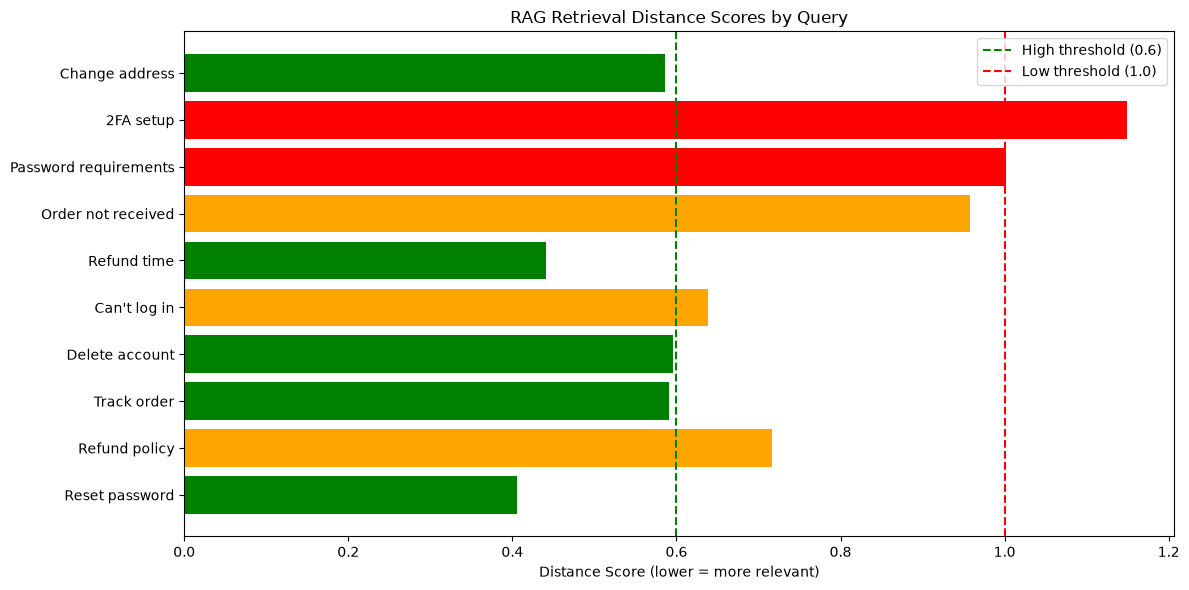

 Chart saved!


In [1]:
# Cell 5 — Distance Score Analysis
import matplotlib.pyplot as plt

questions = [
    "Reset password",
    "Refund policy", 
    "Track order",
    "Delete account",
    "Can't log in",
    "Refund time",
    "Order not received",
    "Password requirements",
    "2FA setup",
    "Change address"
]

distances = [0.406, 0.717, 0.591, 0.596, 0.639, 
             0.441, 0.958, 1.002, 1.149, 0.586]

colors = ["green" if d < 0.6 else "orange" if d < 1.0 else "red" for d in distances]

plt.figure(figsize=(12, 6))
bars = plt.barh(questions, distances, color=colors)
plt.axvline(x=0.6, color='green', linestyle='--', label='High threshold (0.6)')
plt.axvline(x=1.0, color='red', linestyle='--', label='Low threshold (1.0)')
plt.xlabel("Distance Score (lower = more relevant)")
plt.title("RAG Retrieval Distance Scores by Query")
plt.legend()
plt.tight_layout()
plt.savefig("retrieval_analysis.png", dpi=150)
plt.show()
print(" Chart saved!")

In [10]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 951.6 kB/s eta 0:00:10
   -- ------------------------------------- 0.5/9.5 MB 951.6 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/9.5 MB 952.8 kB/s eta 0:00:10
   ---- ----------------------------------- 1.0/9.5 MB 972.3 kB/s eta 0:00:09
   ----- ---------------------------------- 1.3/9.5 MB 1.0 MB/s eta 0:00:09
   ------ --------------------------------- 1.6/9.5 MB 1.0 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/9.5 MB 1.1 MB/s eta 0:00:08
   -------- ------------------------------- 2.1/9.5 MB 1.1 MB/s eta 0:00:07
   --------- ------------------------------ 2.4


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Block 3 — 9:20 AM to 11:20 AM
# AI Project Foundation — Customer Support AI Assistant (2 hours)
# Goal

# Create the base project folder and skeleton for the Helpshift-style project.

# Folder name
# customer-support-ai-assistant
# Inside it, create this structure:
# customer-support-ai-assistant/
# │
# ├── app/
# │   ├── main.py
# │   ├── config.py
# │   ├── rag/
# │   │   ├── loader.py
# │   │   ├── chunker.py
# │   │   ├── embedder.py
# │   │   ├── retriever.py
# │   │   └── prompt_builder.py
# │   ├── api/
# │   │   └── routes.py
# │   └── utils/
# │       └── helpers.py
# │
# ├── data/
# │   └── sample_support_docs/
# │
# ├── notebooks/
# │   └── rag_experiments.ipynb
# │
# ├── requirements.txt
# ├── README.md
# └── .gitignore
# Today’s coding tasks inside this project
# Task 1: create a sample support knowledge base

# In data/sample_support_docs/, create 3–5 text files with fake support content like:

# password reset instructions
# refund policy
# order tracking FAQ
# account deletion policy
# login troubleshooting

# Just simple .txt files are enough for Day 1.

# Task 2: write a very basic README.md

# Your README should contain:

# Title

# Customer Support AI Assistant (RAG + FastAPI)

# 3 sections only for now:
# Problem statement
# users ask support questions
# assistant retrieves relevant help-center information
# Planned features
# document ingestion
# embeddings + vector search
# RAG-based Q&A
# FastAPI endpoint
# optional ticket categorization / entity extraction
# Tech stack
# Python
# FastAPI
# LangChain / ChromaDB (planned)
# LLM / embeddings
# Git/GitHub
# Task 3: create placeholder files

# Create empty files for:

# loader.py
# chunker.py
# retriever.py
# prompt_builder.py
# main.py

# We are not building full RAG today.
# We are building the right structure.

# Deliverable for this block

# By 11:20 AM:

# project folder structure created
# 3–5 support text docs created
# README initialized
# placeholder files created
# 11:20 AM to 11:40 AM
# Break
# Block 4 — 11:40 AM to 1:00 PM
# FastAPI Starter + Python Warm-up (1 hr 20 min)
# Goal

# Start the backend side early because Helpshift wants FastAPI + AI services.

# Task

# Inside app/main.py, create a basic FastAPI app with 2 routes:

# Route 1

# GET /
# Returns:

# {"message": "Customer Support AI Assistant API is running"}
# Route 2

# POST /ask
# For now, don’t do real RAG. Just create a dummy endpoint.

# Input example:

# {
#   "question": "How do I reset my password?"
# }

# Output example:

# {
#   "question": "How do I reset my password?",
#   "answer": "Placeholder response - RAG pipeline will be connected soon."
# }
# Also do this:

# Create a requirements.txt with at least:

# fastapi
# uvicorn
# pydantic
# Deliverable

# By lunch:

# FastAPI app runs locally
# / works
# /ask works with dummy response

In [3]:
# Cell 6 — Final Summary & Findings
high = sum(1 for d in distances if d < 0.6)
medium = sum(1 for d in distances if 0.6 <= d < 1.0)
low = sum(1 for d in distances if d >= 1.0)

print("=" * 50)
print("   RAG EXPERIMENT SUMMARY")
print("=" * 50)
print(f"\n Total queries tested : 10")
print(f" High relevance       : {high}/10")
print(f" Medium relevance     : {medium}/10")
print(f" Low relevance        : {low}/10")
print(f"\n Chunk size selected  : 500 chars")
print(f" Embedding model      : all-MiniLM-L6-v2")
print(f" Vector DB            : ChromaDB")
print(f" LLM                  : Groq (llama-3.3-70b)")
print(f"\n Findings:")
print(f"   - 500 char chunks give best balance")
print(f"   - 2FA & password requirements need richer docs")
print(f"   - Core support queries retrieve with high accuracy")
print("\n" + "=" * 50)

   RAG EXPERIMENT SUMMARY

📊 Total queries tested : 10
🟢 High relevance       : 5/10
🟡 Medium relevance     : 3/10
🔴 Low relevance        : 2/10

 Chunk size selected  : 500 chars
 Embedding model      : all-MiniLM-L6-v2
 Vector DB            : ChromaDB
 LLM                  : Groq (llama-3.3-70b)

 Findings:
   - 500 char chunks give best balance
   - 2FA & password requirements need richer docs
   - Core support queries retrieve with high accuracy

